<a href="https://colab.research.google.com/github/murilobeppler/gbc216_t3_G05/blob/main/lab6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

Faça a plotagem do histograma da imagem, observando o histograma, escolha um valor para definir um threshold

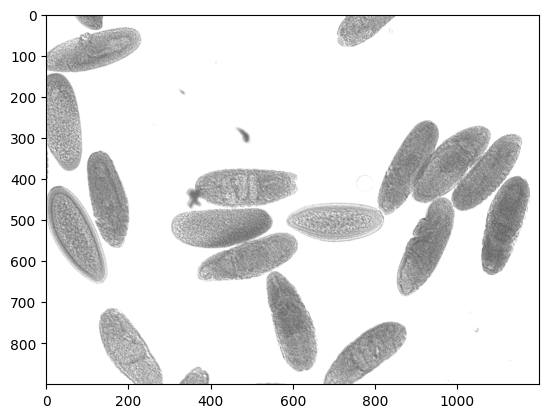

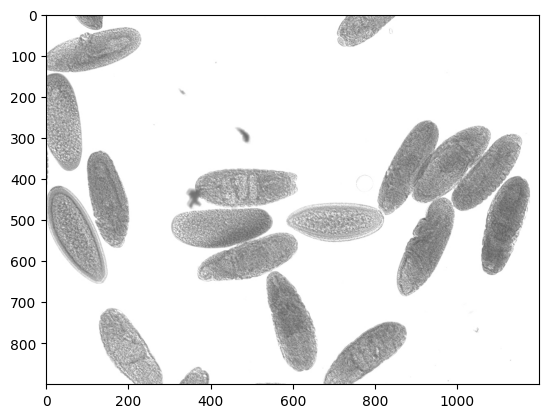

In [2]:
img1 = cv2.imread("insitu107595.jpg", cv2.IMREAD_GRAYSCALE)

plt.imshow(img1, cmap='gray', vmin=0, vmax=255);

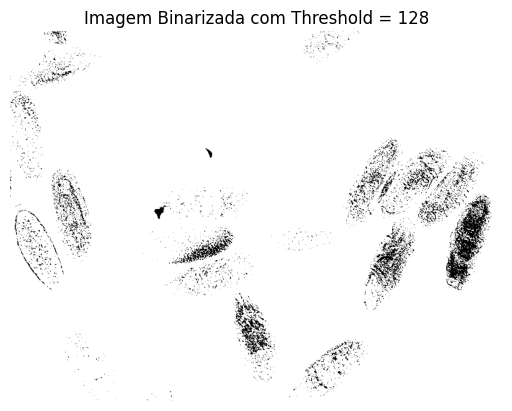

In [3]:
threshold_value = 128 

_, img_thresholded = cv2.threshold(img1, threshold_value, 255, cv2.THRESH_BINARY)

plt.imshow(img_thresholded, cmap='gray', vmin=0, vmax=255)
plt.title(f'Imagem Binarizada com Threshold = {threshold_value}')
plt.axis('off')
plt.show()

4)	Aplique o Otsu para a imagem HE.jpg, madrill.tiff e  Lenna.jpg (use antes a conversão da imagem para tons de cinza)

In [4]:
img1_bgr = cv2.imread("HE.jpg")
img2_bgr = cv2.imread("madrill.tiff")
img3_bgr = cv2.imread("Lenna.jpg")

In [5]:
img1_gray = cv2.cvtColor(img1_bgr, cv2.COLOR_BGR2GRAY)
img2_gray = cv2.cvtColor(img2_bgr, cv2.COLOR_BGR2GRAY)
img3_gray = cv2.cvtColor(img3_bgr, cv2.COLOR_BGR2GRAY)

imagens_gray = [img1_gray, img2_gray, img3_gray]
nomes = ["HE.jpg", "madrill.tiff", "Lenna.jpg"]

APLICAÇÃO DO OTSU EM CADA IMAGEM

In [6]:
limiares = []
imagens_otsu = []

for img_gray in imagens_gray:
    limiar, img_bin = cv2.threshold(
        img_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )
    limiares.append(limiar)
    imagens_otsu.append(img_bin)

for nome, limiar in zip(nomes, limiares):
    print(f"Limiar de Otsu para {nome}: {limiar}")

Limiar de Otsu para HE.jpg: 178.0
Limiar de Otsu para madrill.tiff: 128.0
Limiar de Otsu para Lenna.jpg: 112.0


VISUALIZAÇÃO

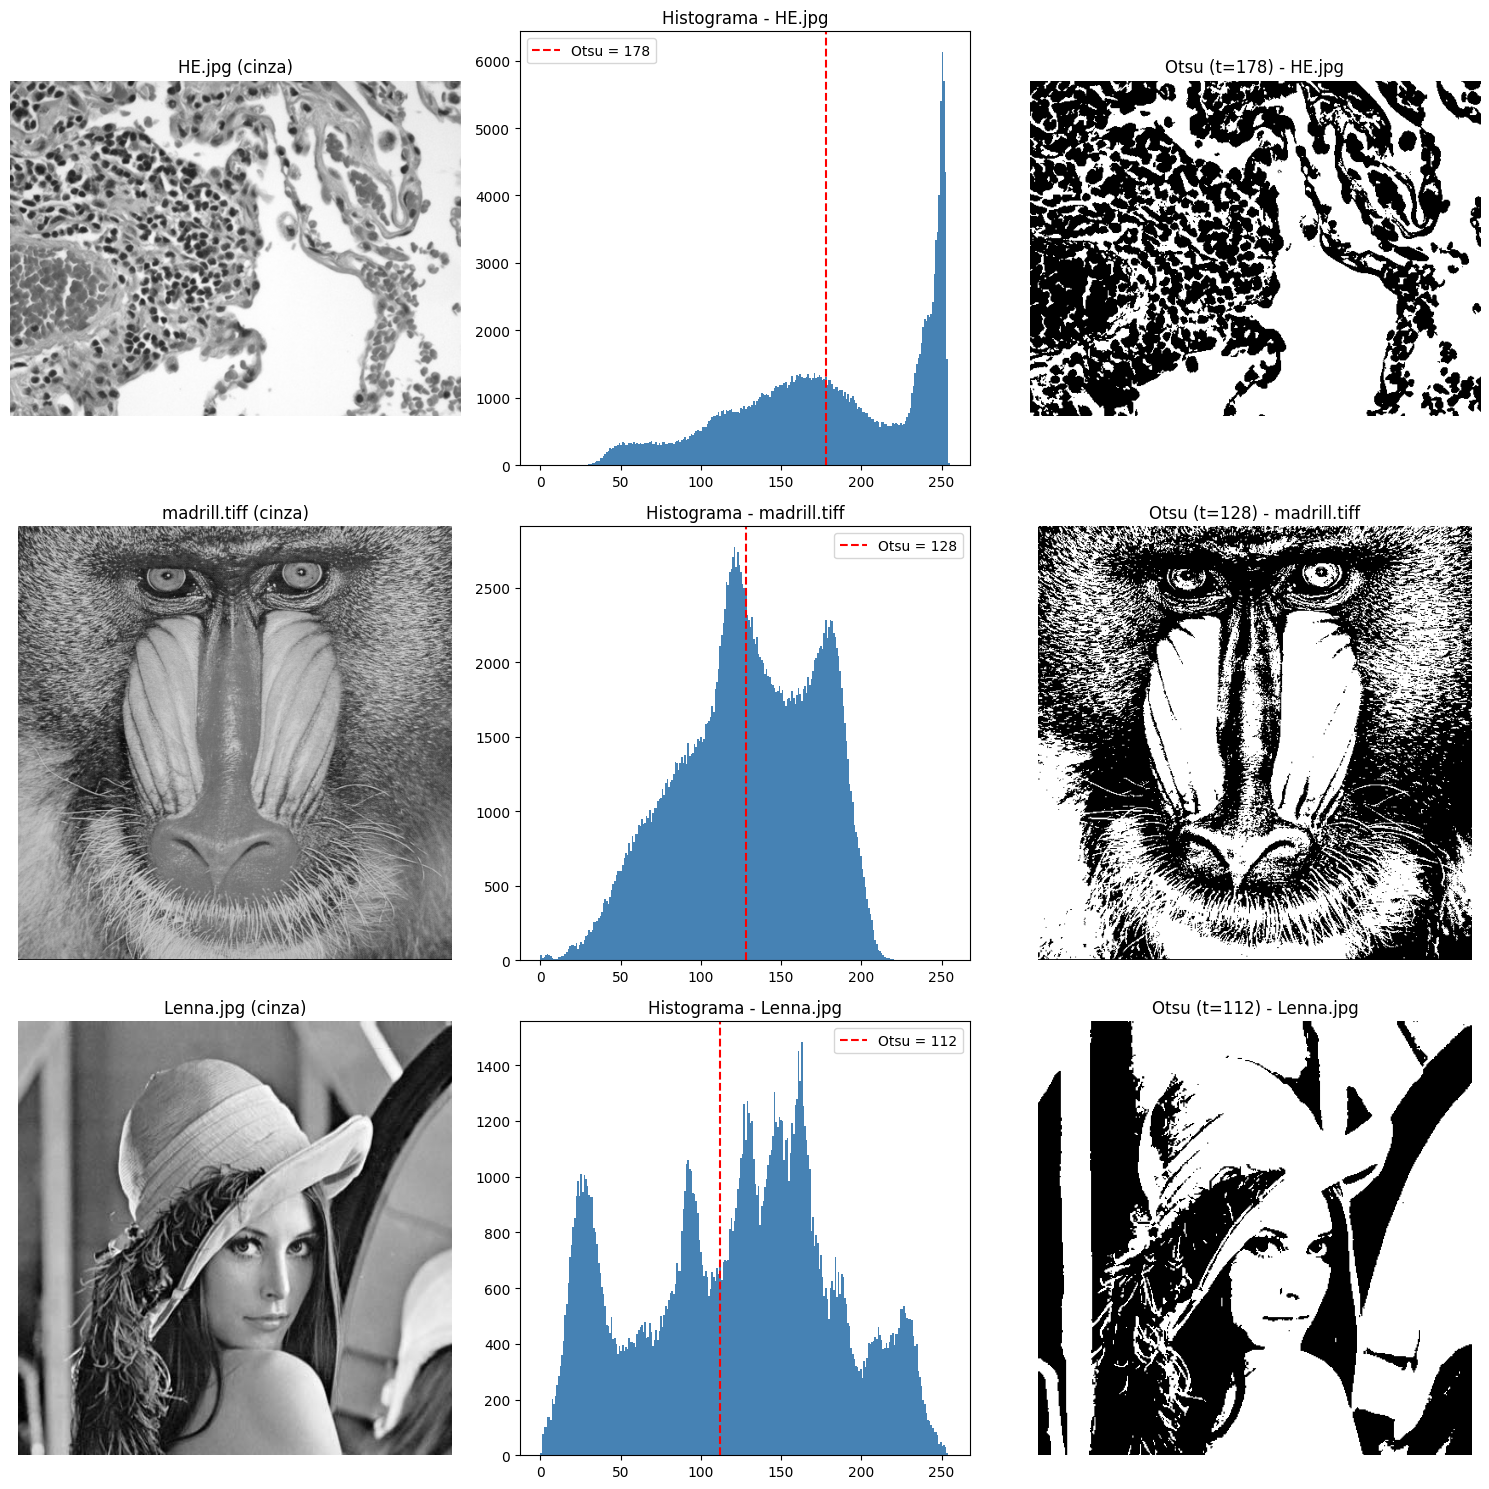

In [7]:
fig, axs = plt.subplots(3, 3, figsize=(15, 15))

for i, (img_gray, img_bin, nome, limiar) in enumerate(
    zip(imagens_gray, imagens_otsu, nomes, limiares)
):
    # Coluna 1: imagem em tons de cinza
    axs[i, 0].imshow(img_gray, cmap='gray', vmin=0, vmax=255)
    axs[i, 0].set_title(f"{nome} (cinza)")
    axs[i, 0].axis('off')

    # Coluna 2: histograma com a linha do limiar de Otsu
    axs[i, 1].hist(img_gray.ravel(), bins=256, range=(0, 255), color='steelblue')
    axs[i, 1].axvline(limiar, color='red', linestyle='--', label=f'Otsu = {limiar:.0f}')
    axs[i, 1].set_title(f"Histograma - {nome}")
    axs[i, 1].legend()

    # Coluna 3: resultado da binarização por Otsu
    axs[i, 2].imshow(img_bin, cmap='gray', vmin=0, vmax=255)
    axs[i, 2].set_title(f"Otsu (t={limiar:.0f}) - {nome}")
    axs[i, 2].axis('off')

plt.tight_layout()
plt.show()